In [10]:
!wget https://raw.githubusercontent.com/yandexdataschool/nlp_course/2024/week02_classification/comments.tsv


--2025-08-20 12:20:51--  https://raw.githubusercontent.com/yandexdataschool/nlp_course/2024/week02_classification/comments.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353358 (345K) [text/plain]
Saving to: ‘comments.tsv’

comments.tsv        100%[===================>] 345.08K  --.-KB/s    in 0.04s   

2025-08-20 12:20:51 (7.76 MB/s) - ‘comments.tsv’ saved [353358/353358]



In [6]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
# so our target is to classify positve (or neutral) and negative comments
# We should do this by several approaches the first one is BAG OF WORDS
# Just count the occurance of the certain word in the sentence (in positive or negative)

# data overview:
import pandas as pd
data = pd.read_csv("/content/comments.tsv", sep='\t')

texts = data['comment_text'].values
target = data['should_ban'].values
data[50::200]

,should_ban,comment_text
50,0,"""Those who're in advantageous positions are th..."
250,1,Fartsalot56 says f**k you motherclucker!!
450,1,"Are you a fool? \n\nI am sorry, but you seem t..."
650,1,I AM NOT A VANDAL!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
850,0,Citing sources\n\nCheck out the Wikipedia:Citi...


In [8]:
from sklearn.model_selection import train_test_split
texts_train, texts_test, y_train, y_test = train_test_split(texts, target, test_size=0.5, random_state=42)

In [9]:
# tokinizes that we will use later
from nltk.tokenize import TweetTokenizer
tokenizer = TweetTokenizer()
preprocess = lambda text: ' '.join(tokenizer.tokenize(text.lower()))

texts_train = [preprocess(text) for text in texts_train]
texts_test = [preprocess(text) for text in texts_test]

print(texts_train[0])
print(texts_test[0])

... oh and what kind of person watches another persons mytalk page ? stalker !
you need a life really bad ... bitch !


In [10]:
assert texts_train[5] ==  'who cares anymore . they attack with impunity .'
assert texts_test[89] == 'hey todds ! quick q ? why are you so gay'
assert len(texts_test) == len(y_test)

In [11]:
# task: find up to k most frequent tokens in texts_train,
# sort them by number of occurences (highest first)
k = 10000

# find the vocab size
occurances = {}
for text in texts_train:
  for word in text.split():
    occurances[word] = occurances.get(word, 0) + 1

bow_vocabulary = [word for word, count in sorted(occurances.items(), key=lambda x: x[1], reverse=True)[:k]]


print('example features:', sorted(bow_vocabulary)[::100])

example features: ['!', '12:20', '300', '_', 'adorned', 'alternative', 'archive', 'average', 'benkner', 'bout', 'came', 'chest', 'combined', 'consumers', 'cricket', 'decisions', 'dickheads', 'domestic', 'eductaion', 'essentially', 'faggot', 'firms', 'frustrated', 'goal', 'hanibal', 'hip-hop', 'identified', 'infoboxes', 'issue', 'kindergarten', 'lets', 'lot', "mclaren's", 'moderator', 'naturally', 'noticeable', 'opposing', 'pdf', 'plant', 'pretoria', 'punctuation', 'rebels', 'repetative', 'riadh', 'schulz', 'shes', 'slit', 'spoof', 'stupid', 't', 'theoretical', 'topic', 'uglyness', 'userspace', 'wanted', 'wikieditor', 'year', '←']


In [12]:
def text_to_bow(text):
    vec = np.zeros(len(bow_vocabulary), dtype='float32')
    for token in text.split():
        if token in bow_vocabulary:
            idx = bow_vocabulary.index(token)
            vec[idx] += 1
    return vec

In [13]:
X_train_bow = np.stack(list(map(text_to_bow, texts_train)))
X_test_bow = np.stack(list(map(text_to_bow, texts_test)))

In [14]:
k_max = len(set(' '.join(texts_train).split()))
assert X_train_bow.shape == (len(texts_train), min(k, k_max))
assert X_test_bow.shape == (len(texts_test), min(k, k_max))
assert np.all(X_train_bow[5:10].sum(-1) == np.array([len(s.split()) for s in  texts_train[5:10]]))
assert len(bow_vocabulary) <= min(k, k_max)
assert X_train_bow[6, bow_vocabulary.index('.')] == texts_train[6].split().count('.')

In [15]:
class BinaryNaiveBayes:
    delta = 1.0  # add this to all word counts to smoothe probabilities

    def fit(self, X, y):
        """
        Fit a NaiveBayes classifier for two classes
        :param X: [batch_size, vocab_size] of bag-of-words features
        :param y: [batch_size] of binary targets {0, 1}
        """
        # first, compute marginal probabilities of every class, p(y=k) for k = 0,1
        self.p_y = np.array([np.sum(y==0)/len(y), np.sum(y==1)/len(y)])

        # count occurences of each word in texts with label 1 and label 0 separately
        self.word_counts_positive = X[y==1].sum(axis=0)
        self.word_counts_negative = X[y==0].sum(axis=0)
        # ^-- both must be vectors of shape [vocab_size].

        # finally, lets use those counts to estimate p(x | y = k) for k = 0, 1

        vocab_size = X.shape[1]
        total_pos = self.word_counts_positive.sum()
        total_neg = self.word_counts_negative.sum()

        self.p_x_given_positive = (self.word_counts_positive + self.delta) / (total_pos + self.delta * vocab_size)
        self.p_x_given_negative = (self.word_counts_negative + self.delta) / (total_neg + self.delta * vocab_size)
        # both must be of shape [vocab_size]; and don't forget to add self.delta!

        return self

    def predict_scores(self, X):
        """
        :param X: [batch_size, vocab_size] of bag-of-words features
        :returns: a matrix of scores [batch_size, k] of scores for k-th class
        """
        # compute scores for positive and negative classes separately.
        # these scores should be proportional to log-probabilities of the respective target {0, 1}
        # note: if you apply logarithm to p_x_given_*, the total log-probability can be written
        # as a dot-product with X
        score_negative = X @ np.log(self.p_x_given_negative) + np.log(self.p_y[0])
        score_positive = X @ np.log(self.p_x_given_positive) + np.log(self.p_y[1])

        # you can compute total p(x | y=k) with a dot product
        return np.stack([score_negative, score_positive], axis=-1)

    def predict(self, X):
        return self.predict_scores(X).argmax(axis=-1)

In [16]:
naive_model = BinaryNaiveBayes().fit(X_train_bow, y_train)

In [17]:
assert naive_model.p_y.shape == (2,) and naive_model.p_y.sum() == 1 and naive_model.p_y[0] > naive_model.p_y[1]
assert naive_model.p_x_given_positive.shape == naive_model.p_x_given_negative.shape == X_train_bow.shape[1:]
assert np.allclose(naive_model.p_x_given_positive.sum(), 1.0)
assert np.allclose(naive_model.p_x_given_negative.sum(), 1.0)
assert naive_model.p_x_given_negative.min() > 0, "did you forget to add delta?"

f_index = bow_vocabulary.index('fuck')  # offensive tweets should contain more of this
assert naive_model.p_x_given_positive[f_index] > naive_model.p_x_given_negative[f_index]

g_index = bow_vocabulary.index('good')  # offensive tweets should contain less of this
assert naive_model.p_x_given_positive[g_index] < naive_model.p_x_given_negative[g_index]

Model accuracy: 0.756
Well done!


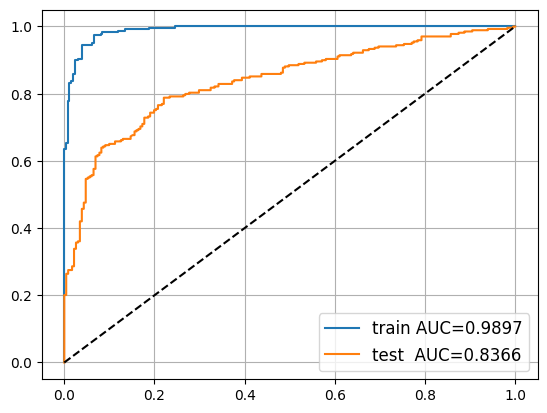

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve

for name, X, y, model in [
    ('train', X_train_bow, y_train, naive_model),
    ('test ', X_test_bow, y_test, naive_model)
]:
    proba = model.predict_scores(X)[:, 1] - model.predict_scores(X)[:, 0]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black',)
plt.legend(fontsize='large')
plt.grid()

test_accuracy = np.mean(naive_model.predict(X_test_bow) == y_test)
print(f"Model accuracy: {test_accuracy:.3f}")
assert test_accuracy > 0.75, "Accuracy too low. There's likely a mistake in the code."
print("Well done!")

# model accuracy is slighly more than needed (

In [19]:
# hint: use naive_model.p_*
probability_ratio = naive_model.p_x_given_positive/naive_model.p_x_given_negative
top_indices = np.argsort(probability_ratio)[-25:][::-1]  # top 25 largest ratios
top_negative_words = [bow_vocabulary[i] for i in top_indices]
print(top_negative_words)

assert len(top_negative_words) == 25 and [isinstance(w, str) for w in top_negative_words]
assert 'j.delanoy' in top_negative_words and 'college' in top_negative_words

for i, word in enumerate(top_negative_words):
    print(f"#{i}\t{word.rjust(10, ' ')}\t(ratio={probability_ratio[bow_vocabulary.index(word)]})")

['hitler', 'heil', 'offfuck', 'suck', 'nigger', 'j.delanoy', 'dick', 'fggt', 'bitch', 'fuck', 'slap', 'shit', 'fucking', 'ass', 'stupid', '=', 'college', '*', 'asshole', 'u', 'hit', 'bastard', 'idiot', '@', 'scientific']
#0	    hitler	(ratio=475.47344970703125)
#1	      heil	(ratio=471.8065185546875)
#2	   offfuck	(ratio=441.2491149902344)
#3	      suck	(ratio=314.7414245605469)
#4	    nigger	(ratio=223.6802978515625)
#5	 j.delanoy	(ratio=220.01341247558594)
#6	      dick	(ratio=187.0113983154297)
#7	      fggt	(ratio=97.78373718261719)
#8	     bitch	(ratio=59.89254379272461)
#9	      fuck	(ratio=53.78105545043945)
#10	      slap	(ratio=44.002681732177734)
#11	      shit	(ratio=44.002681732177734)
#12	   fucking	(ratio=31.779714584350586)
#13	       ass	(ratio=26.890527725219727)
#14	    stupid	(ratio=18.33445167541504)
#15	         =	(ratio=17.53995704650879)
#16	   college	(ratio=17.11215591430664)
#17	         *	(ratio=17.11215591430664)
#18	   asshole	(ratio=15.889857292175293)
#19

Model accuracy: 0.756
Model accuracy: 0.760
Model accuracy: 0.760
Model accuracy: 0.764
Model accuracy: 0.764
Model accuracy: 0.764
Model accuracy: 0.768
Model accuracy: 0.768
Model accuracy: 0.764
Model accuracy: 0.768
Model accuracy: 0.768
Model accuracy: 0.770
Model accuracy: 0.772
Hint: tune the parameter C to improve performance
0.13


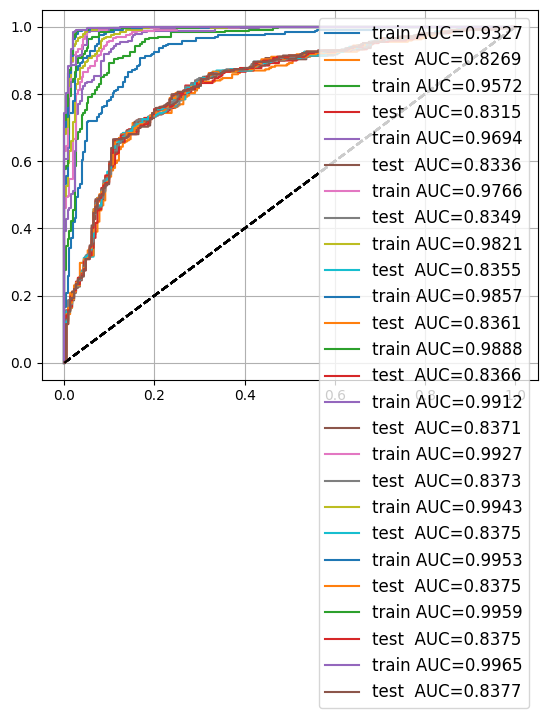

In [20]:
# so now we will do some logistic regression, in the bag of words we just multipled the score of the word by ist occurance and
# based on that decided is the sentence negatice or positive (bias was juat a % of negaivve or positive)
# but now we can train our own W, B and even have an activation function simple sigmoid I suppose!
from sklearn.linear_model import LogisticRegression

for i in range(100):
  c = 0.01 + i/100
  bow_model = LogisticRegression(max_iter=1000, solver='liblinear', C=c)

  #'liblinear' for small datasets, and 1000 number of iterations winin a train to prevent overfitting

  bow_model.fit(X_train_bow, y_train)



  for name, X, y, model in [
      ('train', X_train_bow, y_train, bow_model),
      ('test ', X_test_bow, y_test, bow_model)
  ]:
      proba = model.predict_proba(X)[:, 1]
      auc = roc_auc_score(y, proba)
      plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

  plt.plot([0, 1], [0, 1], '--', color='black',)
  plt.legend(fontsize='large')
  plt.grid()

  test_accuracy = np.mean(bow_model.predict(X_test_bow) == y_test)
  print(f"Model accuracy: {test_accuracy:.3f}")
  if test_accuracy > 0.77:
    print("Hint: tune the parameter C to improve performance")
    print(c)
    break


Model accuracy: 0.772
Well done!


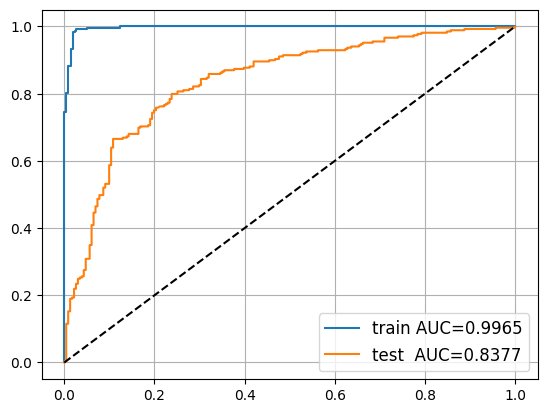

In [21]:
from sklearn.metrics import roc_auc_score, roc_curve


bow_model = LogisticRegression(max_iter=1000, solver='liblinear', C=0.13)
bow_model.fit(X_train_bow, y_train)

for name, X, y, model in [
    ('train', X_train_bow, y_train, bow_model),
    ('test ', X_test_bow, y_test, bow_model)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black',)
plt.legend(fontsize='large')
plt.grid()

test_accuracy = np.mean(bow_model.predict(X_test_bow) == y_test)
print(f"Model accuracy: {test_accuracy:.3f}")
assert test_accuracy > 0.77, "Hint: tune the parameter C to improve performance"
print("Well done!")

In [22]:
# IN A FEW WORDS TF-IDF -> removes no info containing words like "," "a" "I" ...
# if a word appears almost in every document (positive/negative) it has no usefull info wase of computation
N = len(texts_train)
delta = 1.0

df = np.zeros(len(bow_vocabulary), dtype=np.float32)

for text in texts_train:
    words_in_doc = set(text.split())
    for word in words_in_doc:
        if word in bow_vocabulary:
            idx = bow_vocabulary.index(word)
            df[idx] += 1

idf = np.log((N + 1) / (df + 1)) + 1


def text_to_tfidf(text):
    tf = np.zeros(len(bow_vocabulary), dtype=np.float32)
    words = text.split()
    for word in words:
        if word in bow_vocabulary:
            idx = bow_vocabulary.index(word)
            tf[idx] += 1
    # compute tf-idf
    tfidf = tf * idf
    # normalize
    norm = np.linalg.norm(tfidf)
    if norm > 0:
        tfidf /= norm
    return tfidf

X_train_tfidf = np.stack([text_to_tfidf(text) for text in texts_train])
X_test_tfidf = np.stack([text_to_tfidf(text) for text in texts_test])

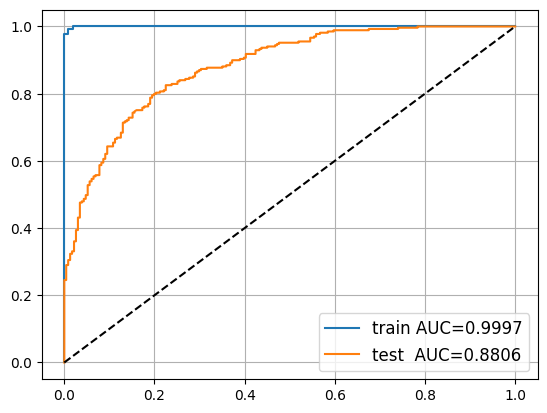

TF-IDF Logistic Regression accuracy: 0.790


In [25]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

tfidf_model = LogisticRegression(max_iter=1000, solver='liblinear', C=5.13)
tfidf_model.fit(X_train_tfidf, y_train)

for name, X, y, model in [
    ('train', X_train_tfidf, y_train, tfidf_model),
    ('test ', X_test_tfidf, y_test, tfidf_model)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black')
plt.legend(fontsize='large')
plt.grid()
plt.show()

test_accuracy = np.mean(tfidf_model.predict(X_test_tfidf) == y_test)
print(f"TF-IDF Logistic Regression accuracy: {test_accuracy:.3f}")

In [26]:
# we will try to further enhance this classifier by using vectors,
# as said in lection we will try to load already done embeddings (they generalize well)
# but we will not fine-tune them (a lot of time)
# we will get 300 dim emb and sum them together to get final inpout into a logistic regression :)
# WHY SUMMING WORKS:
# As I understan pretrained embeddings capute meaning, which menas we can do:
# 'KING' - 'MAN' + 'WOMAN' == 'QUEEN'
# so words like "hate" and "bad" are located near, it is not ideal it cannot capture the logical interconnection
# like BERT transformer but it works well in understanding the meaining that a simple BAG OF WORDS


# downloading
!pip install gensim
import gensim.downloader
embeddings = gensim.downloader.load("fasttext-wiki-news-subwords-300")

KeyboardInterrupt: 

In [30]:
def vectorize_sum(comment):
    """
    Convert preprocessed comment to sum of token vectors
    """
    embedding_dim = embeddings.vectors.shape[1]
    features = np.zeros([embedding_dim], dtype='float32')

    for token in comment.split():
        if token in embeddings:
            features += embeddings[token]


    return features

In [31]:
import numpy as np
X_train_wv = np.stack([vectorize_sum(text) for text in texts_train])
X_test_wv = np.stack([vectorize_sum(text) for text in texts_test])

Max accuracy is:  0.9258436730555689


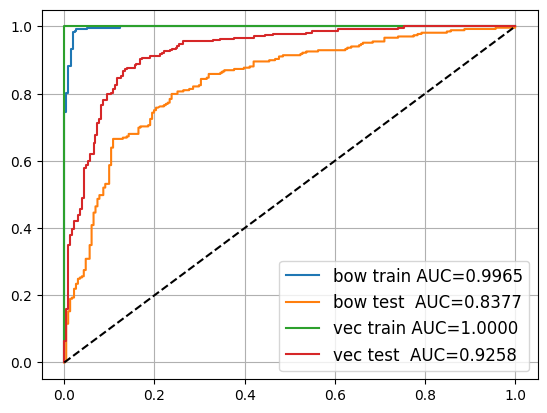

In [35]:
wv_model = LogisticRegression(max_iter = 1000, C=5).fit(X_train_wv, y_train)

for name, X, y, model in [
    ('bow train', X_train_bow, y_train, bow_model),
    ('bow test ', X_test_bow, y_test, bow_model),
    ('vec train', X_train_wv, y_train, wv_model),
    ('vec test ', X_test_wv, y_test, wv_model)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black',)
plt.legend(fontsize='large')
plt.grid()

assert roc_auc_score(y_test, wv_model.predict_proba(X_test_wv)[:, 1]) > 0.92, "something's wrong with your features"
print("Max accuracy is: ", roc_auc_score(y_test, wv_model.predict_proba(X_test_wv)[:, 1]))

# almost ideal :)